# ViT-B/16 + LSTM

In [1]:
#conect with drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
import os
os.environ["GITHUB_TOKEN"] = "github"
os.environ["KAGGLE_USERNAME"] = "kaggle_username"
os.environ["KAGGLE_KEY"] = "kaggle_key"

In [2]:
!dir /content/drive/MyDrive/apai

fetch_src.sh  setup_colab.sh


In [4]:
!sed -i 's/\r$//' /content/drive/MyDrive/apai/fetch_src.sh  # Windows users
!bash /content/drive/MyDrive/apai/fetch_src.sh

 fetch_src.sh — Download /src from GitHub

Checking environment...
GITHUB_TOKEN set
Fetching file list from GitHub API...
Found 15 file(s) under /src/
src/cl_strategies/ewc.py -> /content/src/cl_strategies/ewc.py
src/cl_strategies/naive.py -> /content/src/cl_strategies/naive.py
src/cl_strategies/reharsal.py -> /content/src/cl_strategies/reharsal.py
src/config/config.py -> /content/src/config/config.py
src/data/dataset.py -> /content/src/data/dataset.py
src/data/preprocessing.py -> /content/src/data/preprocessing.py
src/data/study_dataset.py -> /content/src/data/study_dataset.py
src/fine_tune/trainer.py -> /content/src/fine_tune/trainer.py
src/fine_tune/visualizer.py -> /content/src/fine_tune/visualizer.py
src/imports.py -> /content/src/imports.py
src/meta_learning/mamal.py -> /content/src/meta_learning/mamal.py
src/meta_learning/reptil.py -> /content/src/meta_learning/reptil.py
src/models/baselines.py -> /content/src/models/baselines.py
src/models/pretrained.py -> /content/src/models/p

## **Download DATASET**

In [5]:
!sed -i 's/\r$//' /content/drive/MyDrive/apai/setup_colab.sh  # Windows users
!bash /content/drive/MyDrive/apai/setup_colab.sh


UCF101 Project — Colab Setup Script

Checking environment...
KAGGLE_USERNAME set
KAGGLE_KEY set
config.py found

Installing kagglehub...
Done.

Using Colab cache for faster access to the 'ucf101-action-recognition' dataset.
Dataset path: /kaggle/input/ucf101-action-recognition

Detecting path and updating config.py...
Found in Kaggle input: /kaggle/input/ucf101-action-recognition/
DATASET_ROOT = '/kaggle/input/ucf101-action-recognition/'
OUTPUT_ROOT  = '/kaggle/working/ucf101-processed/'

Setup complete!
config.py updated on Drive.
Restarting kernel in 5 seconds...
Dataset cache stays on disk.
Run Cell 3 after restart to verify.
Restarting in 5...
Restarting in 4...
Restarting in 3...
Restarting in 2...
Restarting in 1...


In [6]:
# imports
%run /content/src/imports.py
criterion = nn.CrossEntropyLoss()

Using device: cuda


## **Preprocess the data**

In [7]:
preprocess_dataset()


--- Preprocessing UCF101 ---
From: /kaggle/input/ucf101-action-recognition/
To  : /kaggle/working/ucf101-processed/
Classes: 10 | Limit: Full

Processing split: train



Processing split: val



Processing split: test



Done! Dataset ready at: /kaggle/working/ucf101-processed/


## **DataLoaders**

In [19]:
class_to_idx_10 = {cls: i for i, cls in enumerate(SELECTED_CLASSES)}
print(class_to_idx_10)

TRAIN_DIR = os.path.join(OUTPUT_ROOT, "train")
VAL_DIR = os.path.join(OUTPUT_ROOT, "val")
TEST_DIR = os.path.join(OUTPUT_ROOT, "test")

train_dataset_10 = UCF101Clips(
    TRAIN_DIR,
    class_to_idx_10
)

val_dataset_10 = UCF101Clips(
    VAL_DIR,
    class_to_idx_10
)

test_dataset_10 = UCF101Clips(
    TEST_DIR,
    class_to_idx_10
)

train_loader_10 = DataLoader(train_dataset_10, batch_size=BATCH_SIZE, shuffle=True)
val_loader_10   = DataLoader(val_dataset_10, batch_size=BATCH_SIZE, shuffle=False)
test_loader_10  = DataLoader(test_dataset_10, batch_size=BATCH_SIZE, shuffle=False)

{'PlayingTabla': 0, 'PommelHorse': 1, 'JumpingJack': 2, 'PushUps': 3, 'PoleVault': 4, 'HorseRace': 5, 'HighJump': 6, 'Drumming': 7, 'HorseRiding': 8, 'Diving': 9}


## ViT + LSTM

In [11]:
class ViTLSTM(torch.nn.Module):
    def __init__(self, num_classes=int):
        super().__init__()


        self.classes = num_classes  # Number of output classes

        self.vit = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
        self.vit.heads = torch.nn.Identity()  # Remove the classification head
        self.lstm = torch.nn.LSTM(input_size=768, hidden_size=256, num_layers=2, batch_first=True)

        self.fc = torch.nn.Linear(256, self.classes)  # Classification layer


        # Freeze all ViT parameters except the last 2 encoder layers
        for param in self.vit.parameters():
            param.requires_grad = False

        for i, block in enumerate(self.vit.encoder.layers):
            if i >= 10: 
                for param in block.parameters(): param.requires_grad = True
    
        for param in self.lstm.parameters(): param.requires_grad = True
        
        for param in self.fc.parameters(): param.requires_grad = True

    def forward(self, x):
        # x: [B, T, 3, 224, 224]
        B, T, C, H, W = x.shape

        # Merge batch and time
        x = x.view(B*T, C, H, W)   # [B*T, 3, 224, 224]

        # Pass through ViT
        x = self.vit(x)            # [B*T, 768]

        # Reshape back to sequence
        x = x.view(B, T, -1)       # [B, T, 768]

        # LSTM
        x, _ = self.lstm(x)        # [B, T, 256]

        # Take last time step
        x = x[:, -1, :]            # [B, 256]

        # Classifier
        x = self.fc(x)     # [B, classes]

        return x

In [15]:
vit_lstm = ViTLSTM(num_classes=10)

In [13]:
# Inspect the model's architecture
summary(vit_lstm, input_size=(1, 16, 3, 224, 224))

Layer (type:depth-idx)                             Output Shape              Param #
ViTLSTM                                            [1, 10]                   --
├─VisionTransformer: 1-1                           [16, 768]                 768
│    └─Conv2d: 2-1                                 [16, 768, 14, 14]         (590,592)
│    └─Encoder: 2-2                                [16, 197, 768]            151,296
│    │    └─Dropout: 3-1                           [16, 197, 768]            --
│    │    └─Sequential: 3-2                        [16, 197, 768]            85,054,464
│    │    └─LayerNorm: 3-3                         [16, 197, 768]            (1,536)
│    └─Identity: 2-3                               [16, 768]                 --
├─LSTM: 1-2                                        [1, 16, 256]              1,576,960
├─Linear: 1-3                                      [1, 10]                   2,570
Total params: 87,378,186
Trainable params: 15,755,274
Non-trainable params: 71,

In [16]:
vit_lstm_results = train_model(vit_lstm, train_loader_10, val_loader_10, num_epochs=5)

Epoch [1/5] | Train Acc: 0.8370 Loss: 0.9832 | Val Acc: 0.9394 Loss: 0.1821


Epoch [2/5] | Train Acc: 0.9809 Loss: 0.0822 | Val Acc: 0.9091 Loss: 0.3311


Epoch [3/5] | Train Acc: 0.9899 Loss: 0.0479 | Val Acc: 0.9697 Loss: 0.0936


Epoch [4/5] | Train Acc: 0.9920 Loss: 0.0325 | Val Acc: 0.9758 Loss: 0.0979


Epoch [5/5] | Train Acc: 0.9980 Loss: 0.0118 | Val Acc: 0.9818 Loss: 0.0873


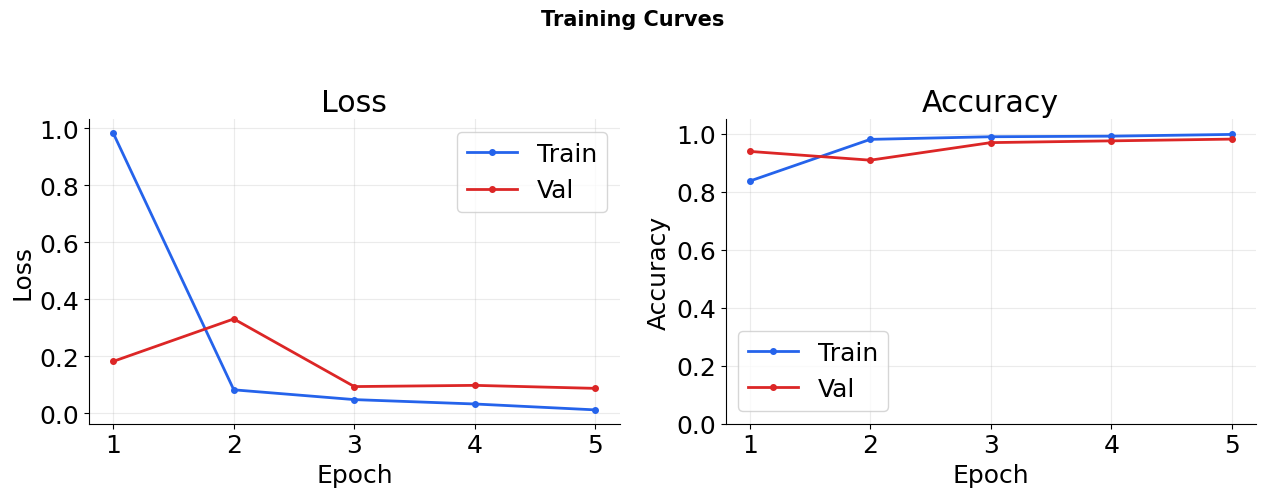

In [22]:
plot_training_results(vit_lstm_results)

In [17]:
test_acc_vit_lstm, all_preds_vit_lstm, all_labels_vit_lstm = test_model(vit_lstm, test_loader_10)

Running Inference on Test Set...


Test Accuracy: 0.9942


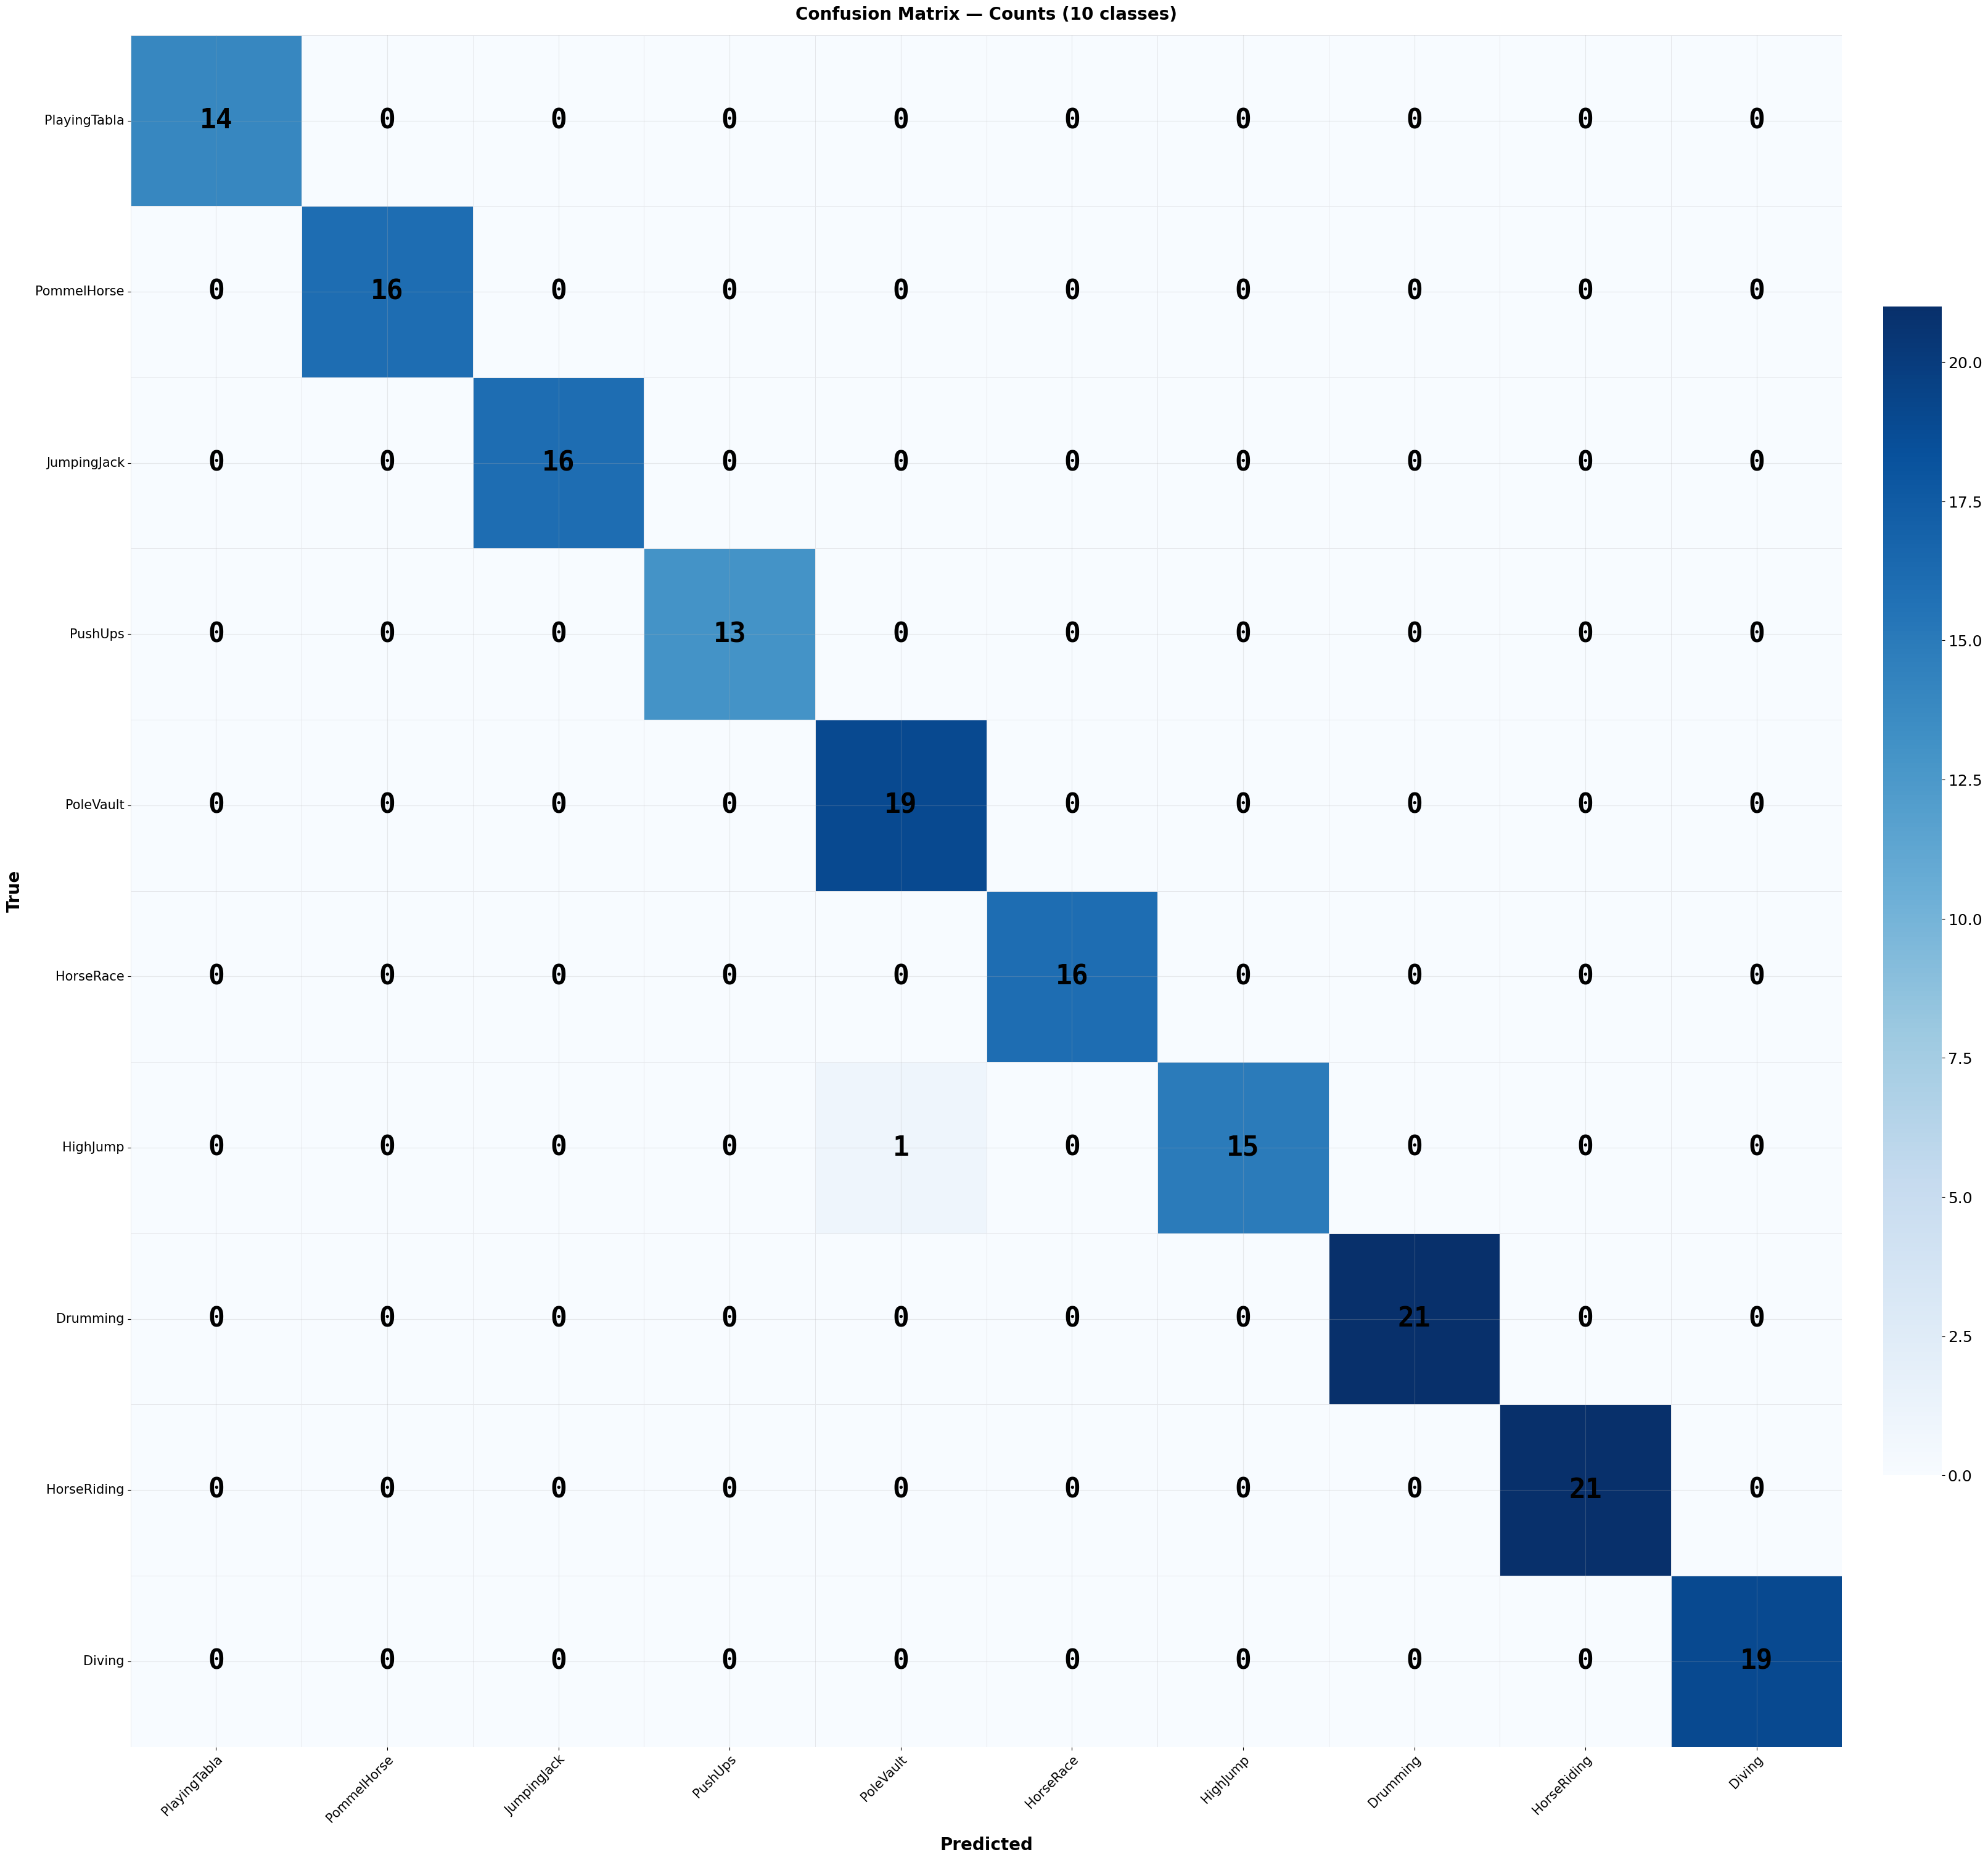

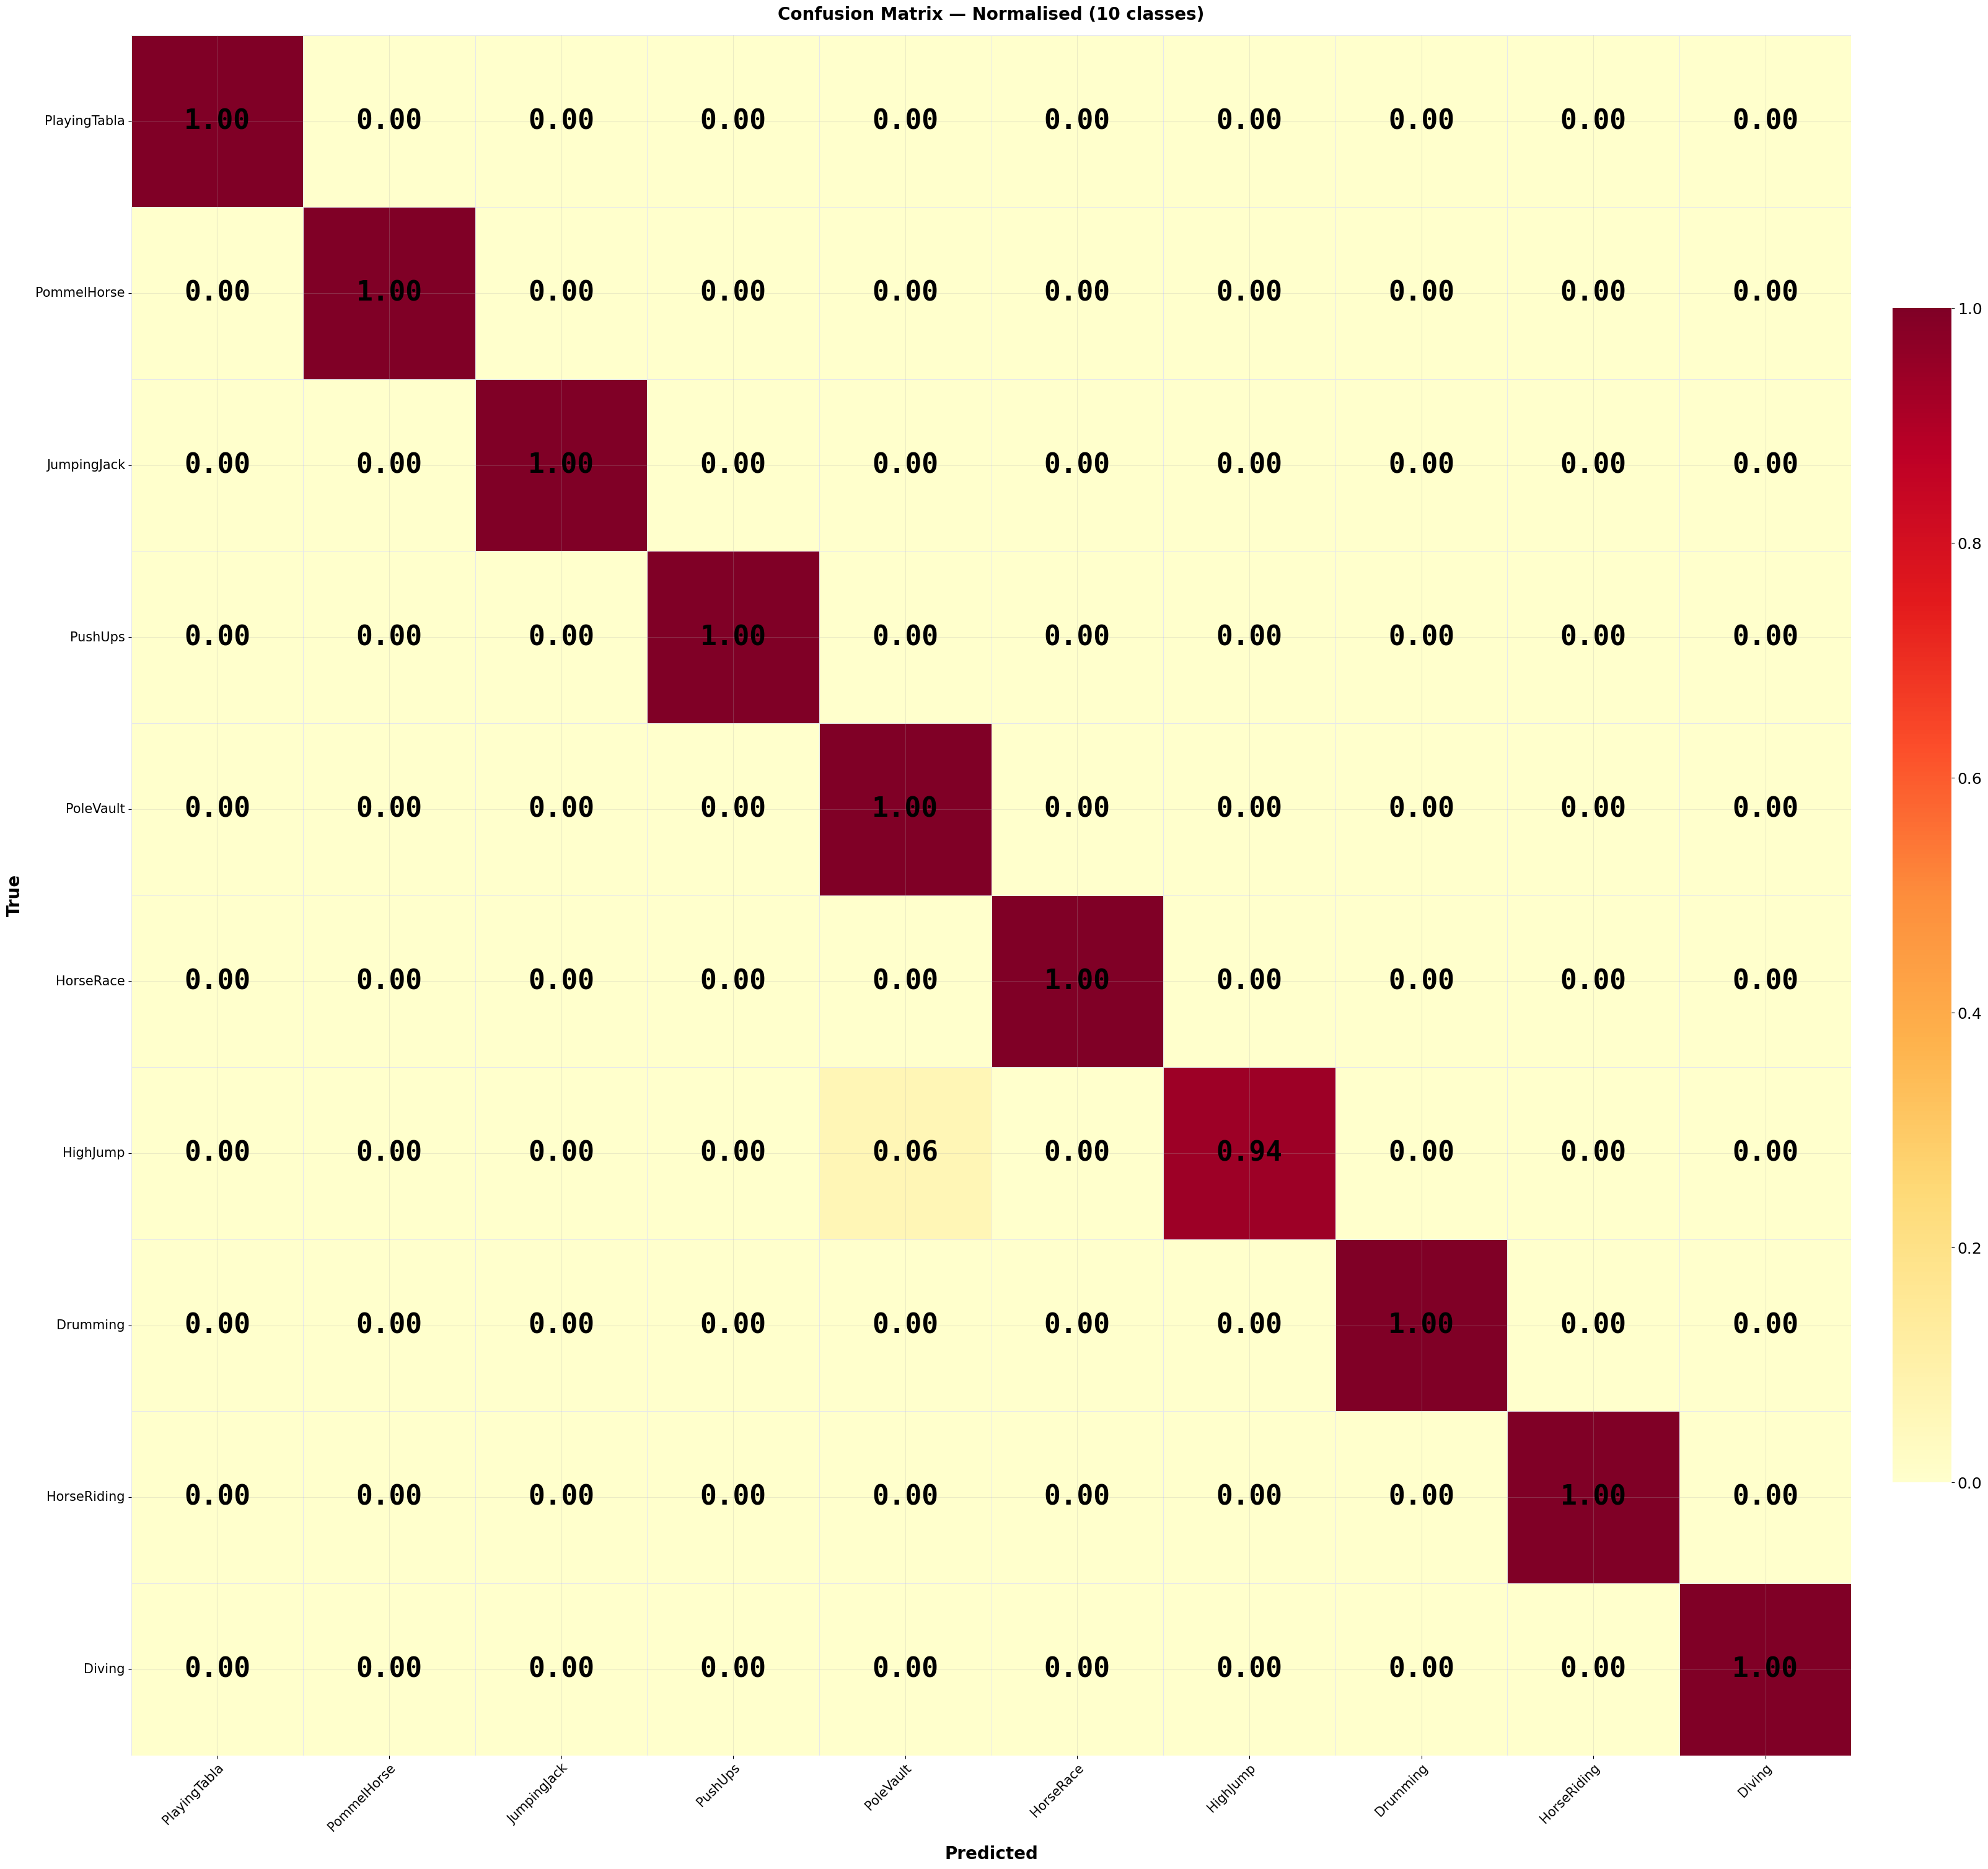

In [18]:
# plot cm
plot_confusion_matrix(all_labels_vit_lstm, all_preds_vit_lstm, num_classes=10, classes_list=SELECTED_CLASSES)

In [20]:
# print detailed metrics
print_detailed_metrics(all_labels_vit_lstm, all_preds_vit_lstm, num_classes=10, classes_list=SELECTED_CLASSES)


METRICS FOR 10 CLASSES
OVERALL (Weighted Average)
  Accuracy  : 0.9942
  Precision : 0.9944
  Recall    : 0.9942
  F1-Score  : 0.9941

PER-CLASS REPORT 
              precision    recall  f1-score   support

PlayingTabla       1.00      1.00      1.00        14
 PommelHorse       1.00      1.00      1.00        16
 JumpingJack       1.00      1.00      1.00        16
     PushUps       1.00      1.00      1.00        13
   PoleVault       0.95      1.00      0.97        19
   HorseRace       1.00      1.00      1.00        16
    HighJump       1.00      0.94      0.97        16
    Drumming       1.00      1.00      1.00        21
 HorseRiding       1.00      1.00      1.00        21
      Diving       1.00      1.00      1.00        19

    accuracy                           0.99       171
   macro avg       0.99      0.99      0.99       171
weighted avg       0.99      0.99      0.99       171

TOP 5 BEST CLASSES (F1)
  1. Diving                   : 1.0000
  2. HorseRiding        

## **Recap**

- ViT-B/16 (ImageNet) + a 2-layer LSTM on the 10 base classes, 5 epochs (Adam, lr 1e-4), the same budget as the CNN backbones.
- Only the last 2 of the 12 encoder blocks, the LSTM and the head are trained: 15.8M of 87.4M parameters.
- Test accuracy 99.4% (val 98.2%) on UCF101's shipped split (171 test clips). On the same split ResNet50 scores 98.2%.
- The shipped split leaks clips of the same recording into the test set, so this number cannot be compared with the group-disjoint results (ResNet50: 93.9%).
- This notebook comes from the earlier pipeline (branch main) and uses that branch's src code, so it runs from main.